In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [23]:
ruta_carpeta = Path(
    "../Resultados/Tabla_de_metricas_por_mes"
)

ruta_salida = Path(
    "../Resultados/Graficos_por_mes"
)
ruta_salida.mkdir(parents=True, exist_ok=True)

Acá abajo seleccionar la métrica que se quiere graficar

In [109]:
# Métrica a evaluar
# puede ser: NS,Pbias,CV,Pearson,CRPSSad,Brier_Q10,Brier_Q10_Q25,Brier_Q25_Q75,Brier_Q75_Q90,Brier_Q90
metrica_evaluar = "CRPSSad"

Seleccione los leadtimes que querés evaluar:

In [110]:
lead_times_evaluar = [1,2,3]

In [111]:
df_evaluacion = []

for ruta_csv in ruta_carpeta.glob("*.csv"):
    df = pd.read_csv(ruta_csv)
    cuenca = ruta_csv.stem

    if metrica_evaluar not in df.columns:
        raise ValueError(f"{metrica_evaluar} no está en {ruta_csv.name}")

    # seleccionar leads times deseados
    df_lead_selec = df[df["lead"].isin(lead_times_evaluar)]
    #print(df_lead_selec)
    
    # promedio sobre leads para cada mes
    df_mes = (
        df_lead_selec
        .groupby("mes")[metrica_evaluar]
        .mean()
        .reset_index()
    )
    print (df_mes)
    
    df_mes["cuenca"] = cuenca
    df_evaluacion.append(df_mes)

#print (df_mes)

    mes   CRPSSad
0     1  0.056764
1     2  0.119542
2     3  0.102079
3     4  0.043527
4     5  0.097367
5     6  0.122223
6     7  0.133136
7     8  0.095700
8     9  0.081052
9    10  0.052041
10   11  0.036748
11   12  0.089201
    mes   CRPSSad
0     1  0.054681
1     2  0.151407
2     3  0.121749
3     4  0.046273
4     5  0.106184
5     6  0.103999
6     7  0.195430
7     8  0.110553
8     9  0.103272
9    10  0.064241
10   11  0.041980
11   12  0.103325
    mes   CRPSSad
0     1  0.073512
1     2  0.080217
2     3  0.086703
3     4  0.044571
4     5  0.078668
5     6  0.091984
6     7  0.174259
7     8  0.115200
8     9  0.096092
9    10  0.063802
10   11  0.058338
11   12  0.064196
    mes   CRPSSad
0     1  0.090768
1     2  0.098477
2     3  0.089482
3     4  0.057124
4     5  0.082925
5     6  0.107975
6     7  0.168808
7     8  0.105369
8     9  0.116117
9    10  0.069199
10   11  0.079550
11   12  0.073363
    mes   CRPSSad
0     1  0.102235
1     2  0.180739
2     3  0

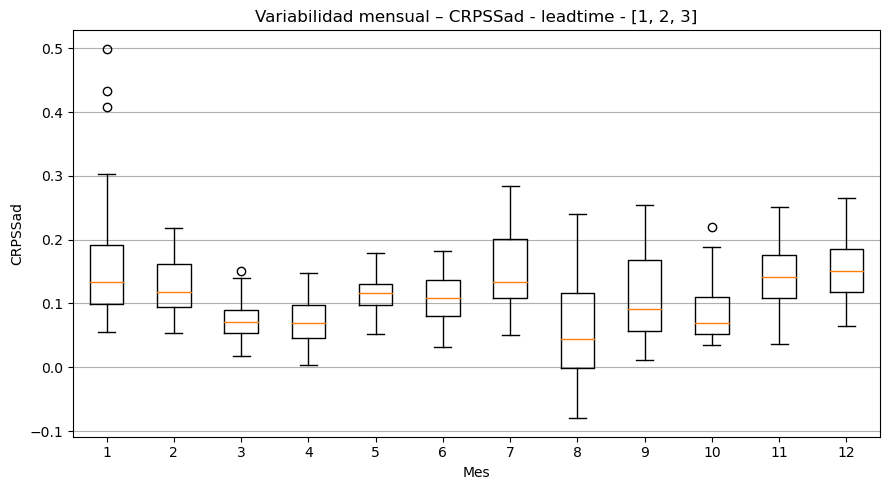

In [112]:
# DataFrame final y graficar

df_evaluacion = pd.concat(df_evaluacion, ignore_index=True)

meses = range(1, 13)

box_data = [
    df_evaluacion.loc[df_evaluacion["mes"] == m, metrica_evaluar].dropna()
    for m in meses
]

plt.figure(figsize=(9, 5))
plt.boxplot(box_data, labels=meses, showfliers=True)
plt.xlabel("Mes")
plt.ylabel(metrica_evaluar)
plt.title(f"Variabilidad mensual – {metrica_evaluar} - leadtime - {lead_times_evaluar}")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(ruta_salida / f"boxplot_mensual_{metrica_evaluar}_lead_{lead_times_evaluar}.png", dpi=300)
plt.show()